In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import math

In [3]:
def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    
    R = 6371.0
    distance = R * c

    return distance

In [4]:
df = pd.read_csv("../data/galicia_census.csv")
gdf = gpd.read_file('../data/galicia_mun.geojson')

# Guaranteed uniqueness (manual data check)
mun_names = gdf['mun_name'].unique()
print(f"There are {len(mun_names)} out of {gdf.shape[0]} unique municipality names")

# Perfect matches (town matches mun_name and no duplicates in original census data)
perfect_matched_rows = df[df['mun'].isin(mun_names) & ~df['mun'].duplicated(keep=False)]
perfect_matched_muns = perfect_matched_rows['mun']

# Leftover original datapoints
leftover_original_data = df[~df['mun'].isin(perfect_matched_muns)]

# Leftover up to date geo datapoints
leftover_geo_data = gdf[~gdf['mun_name'].isin(perfect_matched_muns)]

print(f"{len(perfect_matched_muns)} perfect matches")
print(f"{len(leftover_original_data)} leftover from original datapoints")
print(f"{len(leftover_geo_data)} leftover from geo datapoints")

There are 313 out of 313 unique municipality names
222 perfect matches
328 leftover from original datapoints
91 leftover from geo datapoints


In [5]:
# Greedy algorithm to find closest municipality for each datapoint in the geo leftovers
# 1. Sort the distances in ascending order
# 2. Greedily pick the shortest distances until all pairings have been made (next cell)

distance_list = []
# Get the sorted list of distances
for _, geo_row in leftover_geo_data.iterrows():
    geo_point_2d = geo_row["geo_point_2d"]
    geo_lat, geo_lon = geo_point_2d["lat"], geo_point_2d["lon"]
    
    for _, og_row in leftover_original_data.iterrows():
        og_lat, og_lon = og_row["lat"], og_row["lon"]
        
        curr_dist = haversine(geo_lat, geo_lon, og_lat, og_lon)
        # OG row provides municipality, region, and pop b/c of duplicates
        distance_list.append((geo_row["mun_name"], og_row["mun"], og_row['reg'], og_row['pop'], curr_dist))

distance_list = sorted(distance_list, key=lambda x: x[4])
print(len(distance_list))
print(f"Biggest dist in matches is {max(distance_list, key=lambda x: x[4])}")

29848
Biggest dist in matches is ('O Rosal', 'Rinlo', 'A Mariña Central', 233, 229.07173398280733)


In [6]:
# Greedily choose matches (allow duplicates in og_mun to avoid outliers)
already_matched = set()
matches = []
for geo_mun, og_mun, og_reg, og_pop, dist in distance_list:
    if geo_mun not in already_matched:
        matches.append((geo_mun, og_mun, og_reg, og_pop, dist))
        already_matched.add(geo_mun)
    
print(len(matches))
print(f"Smallest dist in matches is {min(matches, key=lambda x: x[4])}")
print(f"Biggest dist in matches is {max(matches, key=lambda x: x[4])}")
print(f"Average distance in matches is {sum(x[4] for x in matches) / len(matches)}")

91
Smallest dist in matches is ('Boimorto', 'A Gándara', 'Arzúa', 391, 0.18750112758349924)
Biggest dist in matches is ('Baleira', 'Mosteiro', 'A Ulloa', 185, 14.656836559255307)
Average distance in matches is 3.3331059378653354


In [7]:
# Save filtered census data (very unoptimized)
filtered_df = df[df['mun'].isin(perfect_matched_muns)]
filtered_df = filtered_df.drop(columns=['reg'])

print(len(filtered_df))
for geo_mun, og_mun, og_reg, og_pop, dist in matches:
    curr_row = df[(df['mun'] == og_mun) & (df['reg'] == og_reg) & (df['pop'] == og_pop)].drop(columns='reg')
    curr_row['mun'] = geo_mun
    
    filtered_df = pd.concat([filtered_df, curr_row])

filtered_df = filtered_df.sort_values(by='mun')
print(len(filtered_df))

# Use coords from geo datapoints
just_coords = pd.DataFrame({
    'mun': gdf['mun_name'],  # Assuming 'mun_name' is the column with the municipality name
    'lat': gdf['geo_point_2d'].apply(lambda x: x['lat']),
    'lon': gdf['geo_point_2d'].apply(lambda x: x['lon'])
})

filtered_df = filtered_df.merge(just_coords, on='mun', suffixes=('_old', ''))
filtered_df.drop(columns=['lat_old', 'lon_old'], inplace=True)

# Add some new cols
filtered_df["norm_gfrac"] = (filtered_df["gfrac"] / (filtered_df["sfrac"] + filtered_df["gfrac"])).round(3)
filtered_df["norm_sfrac"] = (filtered_df["sfrac"] / (filtered_df["sfrac"] + filtered_df["gfrac"])).round(3)
filtered_df["lang_coeff"] = (filtered_df["norm_gfrac"] - filtered_df["norm_sfrac"]).round(3)
filtered_df["lat"] = filtered_df["lat"].round(3)
filtered_df["lon"] = filtered_df["lon"].round(3)

filtered_df.to_csv('../data/galicia_filtered_census.csv', index=False)

222
313


In [8]:
# Validate the new filtered census data
filtered_df = pd.read_csv("../data/galicia_filtered_census.csv")
print(filtered_df['mun'].nunique())

313


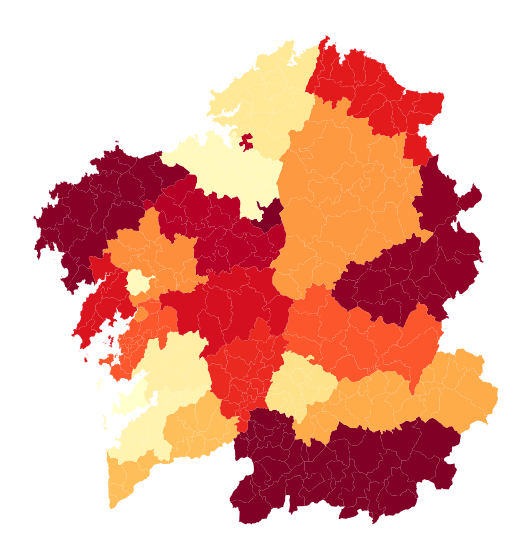

In [12]:
# Visualize the language coefficients over each municipality
merged_gdf = gdf.merge(filtered_df, left_on='mun_name', right_on='mun', how='left')

# Create a colormap based on the lang_coeff values
norm = plt.Normalize(vmin=merged_gdf['lang_coeff'].min(), vmax=merged_gdf['lang_coeff'].max())
cmap = plt.get_cmap('YlOrRd')  # You can use any colormap here

# Plotting
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_axis_off()

# Plot each region with color based on its lang_coeff
merged_gdf.plot(ax=ax, column='lang_coeff', cmap=cmap, linewidth=0.8)
# merged_gdf.plot(ax=ax, column='lang_coeff', cmap=cmap, linewidth=0.8, edgecolor='black', legend=True, legend_kwds={'label': "Language Coefficient", 'orientation': "horizontal",}

# Show the plot
plt.savefig("../output_maps/galicia_groundtruth.png", transparent=True)
plt.show()
plt.close(fig)

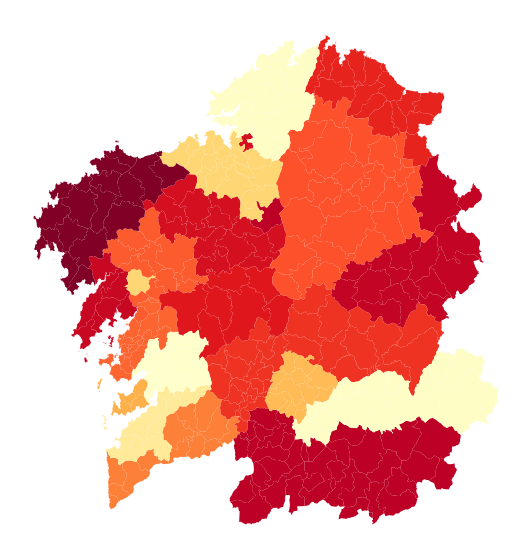

In [13]:
# Create a colormap based on the lang_coeff values
norm = plt.Normalize(vmin=merged_gdf['status'].min(), vmax=merged_gdf['status'].max())
cmap = plt.get_cmap('YlOrRd')  # You can use any colormap here

# Plotting
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_axis_off()

# Plot each region with color based on its lang_coeff
merged_gdf.plot(ax=ax, column='status', cmap=cmap, linewidth=0.8)
# merged_gdf.plot(ax=ax, column='lang_coeff', cmap=cmap, linewidth=0.8, edgecolor='black', legend=True, legend_kwds={'label': "Language Coefficient", 'orientation': "horizontal",}

# Show the plot
plt.savefig("../output_maps/galicia_status.png", transparent=True)
plt.show()
plt.close(fig)